# AgroOptimize HdF — Entraînement final

## Objectif
Prédire la **culture optimale** pour une parcelle agricole des Hauts-de-France
à partir de données officielles françaises.

## Fichiers à uploader (cellule 2)
- `parcelles_hdf.csv` — dataset principal (294 815 parcelles)
- `rendements_agreste_2024.csv` — rendements nationaux Agreste SAA 2024

## Sources des données
| Donnée | Source | URL |
|---|---|---|
| Cultures déclarées | RPG IGN 2024 | geoservices.ign.fr/rpg |
| Précédent cultural | RPG IGN 2023 | geoservices.ign.fr/rpg |
| Sol (texture, pH, argile) | SGDBE INRAE 1/1 000 000 | data.gouv.fr |
| Rendements | Agreste SAA 2023-2024 | agreste.agriculture.gouv.fr |
| DPB 118 €/ha | data.gouv.fr PAC 2022 | data.gouv.fr |
| Éco-régime 62 €/ha | Arrêté JO 01/10/2024 | legifrance.gouv.fr |
| VBC pois 104 €/ha | SMAG PAC 2023-2027 | smag.tech |
| VBC pdt 130 €/ha | Telepac notice PAC 2024 | telepac.agriculture.gouv.fr |

## Modèles comparés
1. **Random Forest** — baseline interprétable
2. **XGBoost** — gradient boosting avec poids plafonnés
3. **LightGBM** — gradient boosting leaf-wise

In [18]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 1 — Installation des packages                  ║
# ║                                                          ║
# ║  Installe toutes les librairies ML nécessaires.          ║
# ║  À exécuter en premier, une seule fois par session.      ║
# ╚══════════════════════════════════════════════════════════╝

!pip install xgboost lightgbm scikit-learn pandas numpy joblib matplotlib seaborn -q
print('✓ Packages installés')

✓ Packages installés


In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Upload des fichiers                         ║
# ║                                                          ║
# ║  Upload 2 fichiers :                                     ║
# ║  1. parcelles_hdf.csv        — dataset principal         ║
# ║     (294 815 parcelles RPG avec sol réel SGDBE)          ║
# ║  2. rendements_agreste_2024.csv — rendements nationaux   ║
# ║     (Agreste SAA 2023-2024, France métropolitaine)       ║
# ╚══════════════════════════════════════════════════════════╝

from google.colab import files
print('Uploader les 2 fichiers : parcelles_hdf.csv + rendements_agreste_2024.csv')
uploaded = files.upload()
print('✓ Fichiers reçus :', list(uploaded.keys()))

Uploader les 2 fichiers : parcelles_hdf.csv + rendements_agreste_2024.csv


Saving parcelles_hdf.csv to parcelles_hdf.csv
Saving rendements_agreste_2024.csv to rendements_agreste_2024.csv
✓ Fichiers reçus : ['parcelles_hdf.csv', 'rendements_agreste_2024.csv']


In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Imports et constantes PAC                   ║
# ║                                                          ║
# ║  Importe toutes les librairies et définit les montants   ║
# ║  PAC 2024 avec leurs sources exactes.                    ║
# ║                                                          ║
# ║  IMPORTANT — Sources des montants PAC :                  ║
# ║  • DPB 118 €/ha                                          ║
# ║    Source : data.gouv.fr — Aides PAC versées 2022        ║
# ║    Fichier : agriculture-france-aides-pac-2022.xlsx      ║
# ║    Onglet : Hypothèses, cellule C2                       ║
# ║                                                          ║
# ║  • Éco-régime niveau supérieur 62 €/ha                   ║
# ║    Source : Arrêté du 25 septembre 2024                  ║
# ║    Publié au JO le 01/10/2024                            ║
# ║    (identique à la campagne 2023)                        ║
# ║                                                          ║
# ║  • Éco-régime niveau de base pdt 45 €/ha                 ║
# ║    Source : même arrêté JO 01/10/2024                    ║
# ║                                                          ║
# ║  • VBC pois protéagineux 104 €/ha                        ║
# ║    Source : SMAG — PAC 2023-2027 guide complet           ║
# ║    URL : smag.tech/blog/guide-pac-2023-2027              ║
# ║                                                          ║
# ║  • VBC pomme de terre industrie 130 €/ha                 ║
# ║    Source : Telepac — Notice aides découplées PAC 2024   ║
# ║    URL : telepac.agriculture.gouv.fr                     ║
# ║                                                          ║
# ║  • SIE supprimé (était 15-30 €/ha)                       ║
# ║    Les SIE ne sont plus subventionnés depuis la          ║
# ║    réforme PAC 2023 — ils deviennent obligatoires        ║
# ║    via les BCAE (conditionnalité non rémunérée)          ║
# ╚══════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import time, json, joblib, warnings, os
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    mean_absolute_error, r2_score, f1_score
)
import xgboost as xgb
import lightgbm as lgb

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Aides PAC 2024 (€/ha) — valeurs réelles sourcées ────────────
PAC_AIDES = {
    # DPB identique pour toutes les cultures éligibles
    # Éco-régime niveau supérieur pour toutes (HdF = rotations diversifiées)
    # sauf pomme de terre (niveau de base car culture industrielle)
    'ble_tendre':     {'dpb': 118, 'eco': 62, 'vbc': 0  },
    'colza':          {'dpb': 118, 'eco': 62, 'vbc': 0  },
    'betterave':      {'dpb': 118, 'eco': 62, 'vbc': 0  },
    'orge':           {'dpb': 118, 'eco': 62, 'vbc': 0  },
    'mais_grain':     {'dpb': 118, 'eco': 62, 'vbc': 0  },
    #'lin_fibre':      {'dpb': 118, 'eco': 62, 'vbc': 0  },
    #'pois_proteine':  {'dpb': 118, 'eco': 62, 'vbc': 104},
    'pomme_de_terre': {'dpb': 118, 'eco': 45, 'vbc': 130},
}
#CULTURES_MODELE = list(PAC_AIDES.keys())
# APRÈS — suppression lin_fibre et pois_proteine
CULTURES_MODELE = [
    'ble_tendre', 'colza', 'betterave', 'pomme_de_terre',
    'orge', 'mais_grain'
]

# Compatibilité sol × culture (score 0-10)
# Source : INRAE / Arvalis — tables de compatibilité pédologique
SOL_IDX = {s:i for i,s in enumerate(
    ['limoneux','argilo_limoneux','sablo_limoneux','craie','tourbe','argileux_lourd'])}
SOL_COMPAT = {
    'ble_tendre':     [10, 8, 5, 6, 4, 6],
    'colza':          [ 9, 7, 4, 5, 3, 5],
    'betterave':      [10, 9, 6, 4, 5, 5],
    'pomme_de_terre': [ 9, 6, 9, 4, 7, 3],
    'lin_fibre':      [10, 7, 5, 5, 4, 4],
    'pois_proteine':  [ 8, 7, 5, 6, 4, 5],
    'orge':           [ 8, 7, 7, 7, 5, 5],
    'mais_grain':     [ 7, 6, 6, 5, 6, 4],
}
# Seuils pluviométriques minimaux (mm) — Source : Arvalis
PLUIE_MIN = {
    'ble_tendre':550, 'colza':600, 'betterave':600,
    'pomme_de_terre':550, 'lin_fibre':600, 'pois_proteine':500,
    'orge':480, 'mais_grain':650,
}

print('=== Aides PAC 2024 — valeurs sourcées ===')
print(f'{"Culture":<20} {"DPB":>6} {"Éco":>6} {"VBC":>6} {"Total":>8}  Notes')
print('-'*70)
for c, v in PAC_AIDES.items():
    total = sum(v.values())
    note = '← aide couplée stratégique' if v['vbc'] == 104 else \
           '← VBC industrie + éco réduit' if v['vbc'] == 130 else ''
    print(f'  {c:<18} {v["dpb"]:>6} {v["eco"]:>6} {v["vbc"]:>6} {total:>8} €/ha  {note}')
print()
print('✓ Constantes chargées')

=== Aides PAC 2024 — valeurs sourcées ===
Culture                 DPB    Éco    VBC    Total  Notes
----------------------------------------------------------------------
  ble_tendre            118     62      0      180 €/ha  
  colza                 118     62      0      180 €/ha  
  betterave             118     62      0      180 €/ha  
  orge                  118     62      0      180 €/ha  
  mais_grain            118     62      0      180 €/ha  
  pomme_de_terre        118     45    130      293 €/ha  ← VBC industrie + éco réduit

✓ Constantes chargées


In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3b — Rendements Agreste SAA 2024                ║
# ║                                                          ║
# ║  Affiche les rendements nationaux extraits des fichiers  ║
# ║  Excel Agreste SAA 2023-2024 (France métropolitaine).    ║
# ║                                                          ║
# ║  Ces rendements ont été utilisés lors de la              ║
# ║  construction de parcelles_hdf.csv pour calculer         ║
# ║  revenu_net_ha = rendement × prix_tonne + PAC - charges. ║
# ║                                                          ║
# ║  Un coefficient régional HdF est appliqué car les        ║
# ║  sols limoneux du nord produisent 10-15% de plus         ║
# ║  que la moyenne nationale.                               ║
# ║  Source coeff : Agreste — Mémento agricole HdF 2023      ║
# ╚══════════════════════════════════════════════════════════╝

rdt = pd.read_csv('rendements_agreste_2024.csv')

# Coefficients régionaux HdF
# Source : Agreste Hauts-de-France — Mémento agricole 2023
# Les sols limoneux de HdF sont parmi les plus fertiles de France
COEFF_HDF = {
    'ble_tendre':1.12, 'colza':1.10, 'betterave':1.02,
    'pomme_de_terre':1.15, 'lin_fibre':1.15, 'pois_proteine':1.08,
    'orge':1.10, 'mais_grain':0.95,
}

print('=== Rendements Agreste SAA 2023-2024 — utilisés dans le modèle ===')
print('Source : Agreste SAA, France métropolitaine')
print('URL    : agreste.agriculture.gouv.fr')
print()
print(f'{"Culture":<22} {"Rdt 2023":>10} {"Rdt 2024":>10} {"Moy nat."}  '
      f'{"Coeff HdF":>10} {"Rdt HdF":>10}')
print('-'*78)
for _, row in rdt.iterrows():
    c = row['culture_key']
    if c not in COEFF_HDF:
        continue
    coeff = COEFF_HDF[c]
    rdt_hdf = round(row['rdt_moy_tha'] * coeff, 2)
    print(f'  {c:<20} {row["rdt_2023_tha"]:>9.2f}  {row["rdt_2024_tha"]:>9.2f}  '
          f'{row["rdt_moy_tha"]:>8.2f}  {coeff:>9.2f}x  {rdt_hdf:>9.2f} t/ha')
print()
print('Lecture : Rdt HdF = Moy nationale × Coeff HdF')
print('         Ces valeurs alimentent revenu_net_ha dans parcelles_hdf.csv')

=== Rendements Agreste SAA 2023-2024 — utilisés dans le modèle ===
Source : Agreste SAA, France métropolitaine
URL    : agreste.agriculture.gouv.fr

Culture                  Rdt 2023   Rdt 2024 Moy nat.   Coeff HdF    Rdt HdF
------------------------------------------------------------------------------
  ble_tendre                7.37       6.09      6.73       1.12x       7.54 t/ha
  colza                     3.18       2.97      3.08       1.10x       3.39 t/ha
  betterave                80.36      79.18     79.77       1.02x      81.37 t/ha
  orge                      6.77       5.41      6.09       1.10x       6.70 t/ha
  mais_grain               10.32       9.55      9.94       0.95x       9.44 t/ha
  lin_fibre                 3.93       6.69      5.31       1.15x       6.11 t/ha
  pois_proteine             3.54       3.19      3.37       1.08x       3.64 t/ha

Lecture : Rdt HdF = Moy nationale × Coeff HdF
         Ces valeurs alimentent revenu_net_ha dans parcelles_hdf.csv


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Chargement et exploration du dataset        ║
# ║                                                          ║
# ║  Charge parcelles_hdf.csv et affiche :                   ║
# ║  • Distribution des cultures vs parts SAU Agreste HdF    ║
# ║  • Taux de données réelles vs simulées par feature       ║
# ║  • Statistiques descriptives du revenu net               ║
# ║  • Vérification des colonnes PAC présentes               ║
# ╚══════════════════════════════════════════════════════════╝

# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Chargement et exploration du dataset        ║
# ╚══════════════════════════════════════════════════════════╝

from google.colab import files

print('Uploader : parcelles_hdf_meteo.csv')
uploaded = files.upload()
CSV_FILE = list(uploaded.keys())[0]

df = pd.read_csv(CSV_FILE)
df = df[df['culture_optimale'].isin(CULTURES_MODELE)].copy()
df = df.reset_index(drop=True)

print(f'\nDataset chargé : {len(df):,} parcelles, {len(df.columns)} colonnes')
print(f'Colonnes : {list(df.columns)}')
print()

# Taux de données réelles vs simulées
print('=== Qualité des données (réel vs simulé) ===')
qualite = {
    'Cultures (RPG 2024)':       ('culture_optimale', 100.0),
    'Précédent (RPG 2023)':      ('precedent_reel',   None),
    'Sol (SGDBE INRAE)':         ('sol_reel',         None),
    'Zone géographique (GPS)':   ('zone_geo',         100.0),
    'Météo (Open-Meteo)':        ('meteo_reelle',     None),
    'Budget intrants':           (None,               0.0),
}
for label, (col, pct_fixe) in qualite.items():
    if pct_fixe is not None:
        pct = pct_fixe
    elif col and col in df.columns:
        pct = df[col].mean() * 100
    else:
        pct = 0.0
    status = '✓ Réel' if pct > 90 else '~ Partiel' if pct > 10 else '✗ Simulé'
    print(f'  {label:<32} {pct:>6.1f}%  {status}')
print()

# Distribution des cultures
print('=== Distribution cultures ===')
dist = df['culture_optimale'].value_counts()
for c, n in dist.items():
    print(f'  {c:<22} {n:>8,}  ({n/len(df)*100:.1f}%)')
print()

# Distribution par zone géographique
print('=== Distribution par zone géographique ===')
print(df['zone_geo'].value_counts().to_string())
print()

# Stats revenu
print('=== Statistiques revenu net €/ha ===')
print(f'  Moyenne  : {df.revenu_net_ha.mean():>8,.0f} €/ha')
print(f'  Médiane  : {df.revenu_net_ha.median():>8,.0f} €/ha')
print(f'  Min/Max  : {df.revenu_net_ha.min():>8,.0f} / {df.revenu_net_ha.max():>8,.0f} €/ha')

Uploader : parcelles_hdf_meteo.csv


Saving parcelles_hdf_meteo.csv to parcelles_hdf_meteo.csv

Dataset chargé : 280,988 parcelles, 18 colonnes
Colonnes : ['id_parcel', 'sol_type', 'argile_pct_sol', 'ph_sol_reel', 'mo_sol_reel', 'pluie_mm', 'temp_moy_c', 'gel_jours', 'surf_parc', 'precedent_cultural', 'precedent_reel', 'budget_intrants_ha', 'sol_reel', 'meteo_reelle', 'culture_optimale', 'revenu_net_ha', 'et0_mm', 'zone_geo']

=== Qualité des données (réel vs simulé) ===
  Cultures (RPG 2024)               100.0%  ✓ Réel
  Précédent (RPG 2023)               66.8%  ~ Partiel
  Sol (SGDBE INRAE)                 100.0%  ✓ Réel
  Zone géographique (GPS)           100.0%  ✓ Réel
  Météo (Open-Meteo)                100.0%  ✓ Réel
  Budget intrants                     0.0%  ✗ Simulé

=== Distribution cultures ===
  ble_tendre              114,878  (40.9%)
  mais_grain               52,190  (18.6%)
  orge                     31,896  (11.4%)
  pomme_de_terre           30,493  (10.9%)
  betterave                30,088  (10.7%)
  co

In [6]:
def enrich(df):
    df = df.copy()
    si = df['sol_type'].map(lambda s: SOL_IDX.get(s, 0))

    # A) Score sol x culture
    for cult, scores in SOL_COMPAT.items():
        df[f'sol_score_{cult}'] = si.map(lambda i, s=scores: s[i] / 10)

    # B) Facteur pluie x culture
    for cult, pmin in PLUIE_MIN.items():
        df[f'pluie_ok_{cult}'] = (df['pluie_mm'] >= pmin).astype(float)

    # C) Features PAC SANS data leakage
    # On n'utilise PAS culture_optimale ici
    df['pac_dpb_fixe']          = 118
    df['pac_eco_base']          = 45
    df['pac_eco_superieur']     = 62
    df['pac_vbc_pdt_possible']  = (df['budget_intrants_ha'] >= 900).astype(int)
    df['pac_vbc_pois_possible'] = (df['budget_intrants_ha'] >= 250).astype(int)
    df['pac_max_atteignable']   = (
        118 + 62
        + df['pac_vbc_pdt_possible'] * 130
        + df['pac_vbc_pois_possible'] * (1 - df['pac_vbc_pdt_possible']) * 104
    )
    df['pac_attractivite'] = (
        (118 + 62) / df['budget_intrants_ha'].clip(lower=1)
    ).round(4)

    # D) Precedent cultural
    df['prec_legumineuse'] = df['precedent_cultural'].isin(
        ['pois_proteine','feveroles']).astype(int)
    df['prec_oleagineux']  = df['precedent_cultural'].isin(
        ['colza','lin_fibre']).astype(int)
    df['prec_cereale']     = df['precedent_cultural'].isin(
        ['ble_tendre','orge','mais_grain','triticale']).astype(int)
    df['prec_betterave']   = (df['precedent_cultural'] == 'betterave').astype(int)
    df['prec_pomme']       = (df['precedent_cultural'] == 'pomme_de_terre').astype(int)

    # E) Contextuelles — vrais noms colonnes parcelles_hdf.csv
    df['argile_norm']     = df['argile_pct_sol'] / 55.0
    df['ph_optimal']      = df['ph_sol_reel'].between(6.5, 7.2).astype(int)
    df['mo_haute']        = (df['mo_sol_reel'] > 3.0).astype(int)
    df['budget_serre']    = (df['budget_intrants_ha'] < 450).astype(int)
    df['budget_ample']    = (df['budget_intrants_ha'] > 800).astype(int)
    df['stress_hydrique'] = (df['pluie_mm'] < 550).astype(int)
    df['surf_relative'] = df['surf_parc'] / df['surf_parc'].mean()

    return df

df = enrich(df)
print(f'Features apres enrichissement : {len(df.columns)} colonnes')
print()
print('=== Features PAC creees (sans leakage) ===')
pac_feats = ['pac_dpb_fixe','pac_eco_base','pac_eco_superieur',
             'pac_vbc_pdt_possible','pac_vbc_pois_possible',
             'pac_max_atteignable','pac_attractivite']
for f in pac_feats:
    if f in df.columns:
        print(f'  {f:<28} moy={df[f].mean():.3f}  min={df[f].min():.1f}  max={df[f].max():.1f}')


Features apres enrichissement : 53 colonnes

=== Features PAC creees (sans leakage) ===
  pac_dpb_fixe                 moy=118.000  min=118.0  max=118.0
  pac_eco_base                 moy=45.000  min=45.0  max=45.0
  pac_eco_superieur            moy=62.000  min=62.0  max=62.0
  pac_vbc_pdt_possible         moy=0.461  min=0.0  max=1.0
  pac_vbc_pois_possible        moy=1.000  min=1.0  max=1.0
  pac_max_atteignable          moy=295.975  min=284.0  max=310.0
  pac_attractivite             moy=0.226  min=0.1  max=0.5


In [7]:
# departement absent du dataset -> retire de FEAT_CAT
FEAT_CAT = ['sol_type', 'precedent_cultural', 'zone_geo']  # ajout zone_geo

COLS_EXCLURE = [
    'culture_optimale', 'revenu_net_ha',
    'precedent_reel', 'sol_reel', 'meteo_reelle',
    'id_parcel', 'lat', 'lon',                    # ajout lat/lon
    'argile_pct_sol', 'ph_sol_reel', 'mo_sol_reel','et0_mm',
]

FEAT_NUM = [c for c in df.columns if c not in FEAT_CAT + COLS_EXCLURE]

print(f'Features categorielles ({len(FEAT_CAT)}) : {FEAT_CAT}')
print(f'Features numeriques    ({len(FEAT_NUM)}) :')
for i, f in enumerate(FEAT_NUM):
    print(f'  {i+1:2d}. {f}')
print(f'\nTotal features : {len(FEAT_CAT) + len(FEAT_NUM)}')

# Verification leakage
le_check = LabelEncoder()
yc_check = le_check.fit_transform(df['culture_optimale'])
print()
print('=== Verification data leakage ===')
suspects = []
for col in FEAT_NUM:
    corr = abs(np.corrcoef(df[col].fillna(0), yc_check)[0,1])
    if corr > 0.3:
        suspects.append((col, corr))
        print(f'  LEAKAGE : {col} correlation={corr:.3f}')
if not suspects:
    print('  OK — aucun leakage detecte (toutes correlations < 0.30)')

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
le = LabelEncoder()

X  = df[FEAT_CAT + FEAT_NUM].copy()
X[FEAT_CAT] = oe.fit_transform(X[FEAT_CAT])
yc = le.fit_transform(df['culture_optimale'])
yr = df['revenu_net_ha'].values

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
tr_idx, te_idx = next(sss.split(X, yc))
X_tr,  X_te  = X.iloc[tr_idx].values, X.iloc[te_idx].values
yc_tr, yc_te = yc[tr_idx], yc[te_idx]
yr_tr, yr_te = yr[tr_idx], yr[te_idx]

print(f'\nTrain : {len(X_tr):,} parcelles')
print(f'Test  : {len(X_te):,} parcelles')
print(f'Classes : {list(le.classes_)}')
print()
print('=== Verification stratification train/test ===')
print(f'{"Culture":<22} {"Train %":>8} {"Test %":>8}')
_, cnt_tr = np.unique(yc_tr, return_counts=True)
_, cnt_te = np.unique(yc_te, return_counts=True)
for i, cls in enumerate(le.classes_):
    pct_tr = cnt_tr[i]/len(yc_tr)*100
    pct_te = cnt_te[i]/len(yc_te)*100
    print(f'  {cls:<20} {pct_tr:>8.1f}% {pct_te:>8.1f}%')


Features categorielles (3) : ['sol_type', 'precedent_cultural', 'zone_geo']
Features numeriques    (40) :
   1. pluie_mm
   2. temp_moy_c
   3. gel_jours
   4. surf_parc
   5. budget_intrants_ha
   6. sol_score_ble_tendre
   7. sol_score_colza
   8. sol_score_betterave
   9. sol_score_pomme_de_terre
  10. sol_score_lin_fibre
  11. sol_score_pois_proteine
  12. sol_score_orge
  13. sol_score_mais_grain
  14. pluie_ok_ble_tendre
  15. pluie_ok_colza
  16. pluie_ok_betterave
  17. pluie_ok_pomme_de_terre
  18. pluie_ok_lin_fibre
  19. pluie_ok_pois_proteine
  20. pluie_ok_orge
  21. pluie_ok_mais_grain
  22. pac_dpb_fixe
  23. pac_eco_base
  24. pac_eco_superieur
  25. pac_vbc_pdt_possible
  26. pac_vbc_pois_possible
  27. pac_max_atteignable
  28. pac_attractivite
  29. prec_legumineuse
  30. prec_oleagineux
  31. prec_cereale
  32. prec_betterave
  33. prec_pomme
  34. argile_norm
  35. ph_optimal
  36. mo_haute
  37. budget_serre
  38. budget_ample
  39. stress_hydrique
  40. surf_rela

In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 7 — Poids par classe (plafonnés à 3x)           ║
# ║                                                          ║
# ║  Problème : blé tendre = 39% du dataset,                 ║
# ║             pois protéagineux = 0.9%                     ║
# ║  → Sans pondération, le modèle prédit presque toujours   ║
# ║    blé et ignore pois.                                   ║
# ║                                                          ║
# ║  Solution : poids inversement proportionnels à la        ║
# ║  fréquence, PLAFONNÉS à 3x.                              ║
# ║                                                          ║
# ║  Pourquoi 3x et pas plus ?                               ║
# ║  Tests précédents : poids non plafonnés → pois poids     ║
# ║  = 45x blé → le modèle sacrifie blé (F1 0.82→0.68)      ║
# ║  → accuracy globale chute de 53% à 49%.                  ║
# ║  Plafond 3x = meilleur compromis empiriquement.          ║
# ╚══════════════════════════════════════════════════════════╝

unique_classes, counts = np.unique(yc_tr, return_counts=True)
n_total   = len(yc_tr)
n_classes = len(unique_classes)

weights_raw    = n_total / (n_classes * counts)
weight_min     = weights_raw.min()
weights_capped = np.minimum(weights_raw, weight_min * 3.0)
class_weight_dict = dict(zip(unique_classes, weights_capped))

print('=== Poids par classe (plafonnés à 3x le poids minimum) ===')
print(f'{"Culture":<22} {"N train":>8} {"% dataset":>10} '
      f'{"Poids brut":>12} {"Poids final":>12}')
print('-'*70)
for cls, cnt, w_raw, w_cap in zip(
        le.classes_, counts, weights_raw, weights_capped):
    plafonn = ' ← plafonné' if w_raw > w_cap + 0.001 else ''
    print(f'  {cls:<20} {cnt:>8,} {cnt/n_total*100:>9.1f}%  '
          f'{w_raw:>10.2f}x  {w_cap:>10.2f}x{plafonn}')

=== Poids par classe (plafonnés à 3x le poids minimum) ===
Culture                 N train  % dataset   Poids brut  Poids final
----------------------------------------------------------------------
  betterave              24,070      10.7%        1.56x        1.22x ← plafonné
  ble_tendre             91,902      40.9%        0.41x        0.41x
  colza                  17,155       7.6%        2.18x        1.22x ← plafonné
  mais_grain             41,752      18.6%        0.90x        0.90x
  orge                   25,517      11.4%        1.47x        1.22x ← plafonné
  pomme_de_terre         24,394      10.9%        1.54x        1.22x ← plafonné


In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 8 — Modèle 1 : Random Forest (baseline)         ║
# ║                                                          ║
# ║  Le Random Forest entraîne N arbres de décision en       ║
# ║  parallèle sur des sous-ensembles aléatoires de données  ║
# ║  et de features, puis vote à la majorité.                ║
# ║                                                          ║
# ║  Rôle : baseline de référence. Si XGBoost/LightGBM       ║
# ║  ne font pas mieux, il y a un problème.                  ║
# ║                                                          ║
# ║  Paramètres :                                            ║
# ║  • n_estimators=200 : 200 arbres                         ║
# ║  • max_depth=20 : arbres profonds                        ║
# ║  • class_weight='balanced' : pondération automatique     ║
# ╚══════════════════════════════════════════════════════════╝

print('Entraînement Random Forest (baseline)...')
t0 = time.time()

rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1,
)
rf_clf.fit(X_tr, yc_tr)
yc_pred_rf = rf_clf.predict(X_te)
acc_rf = accuracy_score(yc_te, yc_pred_rf)
dt_rf  = time.time() - t0

print(f'\n✓ Random Forest — Accuracy : {acc_rf*100:.1f}%  [{dt_rf:.0f}s]')
print()
print(classification_report(yc_te, yc_pred_rf, target_names=le.classes_, zero_division=0))

Entraînement Random Forest (baseline)...

✓ Random Forest — Accuracy : 55.8%  [56s]

                precision    recall  f1-score   support

     betterave       0.32      0.35      0.34      6018
    ble_tendre       0.83      0.80      0.81     22976
         colza       0.34      0.37      0.35      4288
    mais_grain       0.43      0.41      0.42     10438
          orge       0.39      0.29      0.33      6379
pomme_de_terre       0.39      0.53      0.45      6099

      accuracy                           0.56     56198
     macro avg       0.45      0.46      0.45     56198
  weighted avg       0.57      0.56      0.56     56198



In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 9 — Modèle 2 : XGBoost + poids plafonnés        ║
# ║                                                          ║
# ║  XGBoost (eXtreme Gradient Boosting) : construit les     ║
# ║  arbres séquentiellement, chacun corrigeant les erreurs  ║
# ║  du précédent (contrairement au RF qui travaille en      ║
# ║  parallèle).                                             ║
# ║                                                          ║
# ║  early_stopping_rounds=30 : arrête automatiquement si    ║
# ║  la loss ne s'améliore pas sur 30 arbres consécutifs.    ║
# ║  Évite le sur-apprentissage.                             ║
# ║                                                          ║
# ║  sample_weight : poids de la cellule 7 (plafonnés 3x)   ║
# ╚══════════════════════════════════════════════════════════╝

print('Entraînement XGBoost + poids plafonnés...')
t0 = time.time()

X_fit, X_val, y_fit, y_val = train_test_split(
    X_tr, yc_tr, test_size=0.1,
    random_state=RANDOM_SEED, stratify=yc_tr
)
w_fit = np.array([class_weight_dict[y] for y in y_fit])

clf_xgb = xgb.XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=3, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', tree_method='hist',
    random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=30, verbosity=0,
)
clf_xgb.fit(
    X_fit, y_fit, sample_weight=w_fit,
    eval_set=[(X_val, y_val)], verbose=50,
)

yc_pred_xgb = clf_xgb.predict(X_te)
acc_xgb = accuracy_score(yc_te, yc_pred_xgb)
dt_xgb  = time.time() - t0

print(f'\n✓ XGBoost — Accuracy : {acc_xgb*100:.1f}%  [{dt_xgb:.0f}s]')
print(f'  Arbres utilisés : {clf_xgb.best_iteration}')
print()
print(classification_report(yc_te, yc_pred_xgb, target_names=le.classes_, zero_division=0))

Entraînement XGBoost + poids plafonnés...
[0]	validation_0-mlogloss:1.68553
[50]	validation_0-mlogloss:1.16656
[100]	validation_0-mlogloss:1.10898
[150]	validation_0-mlogloss:1.09804
[200]	validation_0-mlogloss:1.09488
[250]	validation_0-mlogloss:1.09327
[300]	validation_0-mlogloss:1.09264
[350]	validation_0-mlogloss:1.09199
[400]	validation_0-mlogloss:1.09177
[450]	validation_0-mlogloss:1.09175
[458]	validation_0-mlogloss:1.09180

✓ XGBoost — Accuracy : 57.3%  [79s]
  Arbres utilisés : 428

                precision    recall  f1-score   support

     betterave       0.36      0.37      0.36      6018
    ble_tendre       0.84      0.78      0.81     22976
         colza       0.47      0.30      0.37      4288
    mais_grain       0.43      0.49      0.46     10438
          orge       0.39      0.33      0.36      6379
pomme_de_terre       0.40      0.58      0.47      6099

      accuracy                           0.57     56198
     macro avg       0.48      0.47      0.47     561

In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 10 — Modèle 3 : LightGBM + class_weight         ║
# ║                                                          ║
# ║  LightGBM : similaire à XGBoost mais croissance          ║
# ║  leaf-wise (par feuille) au lieu de level-wise.          ║
# ║  → Capture mieux les patterns rares comme pois/lin.      ║
# ║  → Généralement plus rapide que XGBoost.                 ║
# ╚══════════════════════════════════════════════════════════╝

print('Entraînement LightGBM + class_weight...')
t0 = time.time()

clf_lgb = lgb.LGBMClassifier(
    n_estimators=500, max_depth=10, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=1.0,
    class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
)
clf_lgb.fit(
    X_tr, yc_tr,
    eval_set=[(X_te, yc_te)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(100)],
)

yc_pred_lgb = clf_lgb.predict(X_te)
acc_lgb = accuracy_score(yc_te, yc_pred_lgb)
dt_lgb  = time.time() - t0

print(f'\n✓ LightGBM — Accuracy : {acc_lgb*100:.1f}%  [{dt_lgb:.0f}s]')
print()
print(classification_report(yc_te, yc_pred_lgb, target_names=le.classes_, zero_division=0))

Entraînement LightGBM + class_weight...
[100]	valid_0's multi_logloss: 1.12202
[200]	valid_0's multi_logloss: 1.11958
[300]	valid_0's multi_logloss: 1.11919

✓ LightGBM — Accuracy : 55.8%  [61s]

                precision    recall  f1-score   support

     betterave       0.34      0.35      0.35      6018
    ble_tendre       0.85      0.77      0.80     22976
         colza       0.34      0.43      0.38      4288
    mais_grain       0.46      0.38      0.41     10438
          orge       0.40      0.33      0.36      6379
pomme_de_terre       0.38      0.60      0.46      6099

      accuracy                           0.56     56198
     macro avg       0.46      0.48      0.46     56198
  weighted avg       0.58      0.56      0.56     56198



In [12]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 11 — Comparaison des 3 modèles                  ║
# ║                                                          ║
# ║  Tableau comparatif :                                    ║
# ║  • Accuracy globale                                      ║
# ║  • F1-score macro (moyenne par classe)                   ║
# ║  • F1 par culture (pour identifier les points faibles)   ║
# ║  • Temps d'entraînement                                  ║
# ╚══════════════════════════════════════════════════════════╝

resultats = {
    'Random Forest': {'pred':yc_pred_rf,  'acc':acc_rf,  'temps':dt_rf,  'clf':rf_clf},
    'XGBoost':       {'pred':yc_pred_xgb, 'acc':acc_xgb, 'temps':dt_xgb, 'clf':clf_xgb},
    'LightGBM':      {'pred':yc_pred_lgb, 'acc':acc_lgb, 'temps':dt_lgb, 'clf':clf_lgb},
}

print('=' * 65)
print('  COMPARAISON DES 3 MODÈLES')
print('=' * 65)
print(f'{"Modèle":<20} {"Accuracy":>10} {"F1 macro":>10} {"Temps":>8}')
print('-' * 52)
for nom, res in resultats.items():
    f1 = f1_score(yc_te, res['pred'], average='macro', zero_division=0)
    res['f1_macro'] = f1
    print(f'  {nom:<18} {res["acc"]*100:>9.1f}%  {f1:>9.3f}  {res["temps"]:>6.0f}s')
print()

# F1 par culture
print('=== F1-score par culture ===')
header = f'{"Culture":<22}'
for nom in resultats: header += f'  {nom[:12]:>12}'
print(header)
print('-' * (22 + 14*len(resultats)))
for i, cls in enumerate(le.classes_):
    line = f'  {cls:<20}'
    for nom, res in resultats.items():
        f1_cls = f1_score(yc_te, res['pred'],
                          labels=[i], average='macro', zero_division=0)
        line += f'  {f1_cls:>12.3f}'
    print(line)

# Meilleur modèle
best_nom = max(resultats, key=lambda k: resultats[k]['acc'])
best_clf = resultats[best_nom]['clf']
best_acc = resultats[best_nom]['acc']
print(f'\n→ Meilleur modèle : {best_nom} ({best_acc*100:.1f}%)')
print(f'  Vs baseline aléatoire : {100/len(le.classes_):.1f}% '
      f'(gain : +{best_acc*100 - 100/len(le.classes_):.1f} pts)')

  COMPARAISON DES 3 MODÈLES
Modèle                 Accuracy   F1 macro    Temps
----------------------------------------------------
  Random Forest           55.8%      0.451      56s
  XGBoost                 57.3%      0.471      79s
  LightGBM                55.8%      0.462      61s

=== F1-score par culture ===
Culture                 Random Fores       XGBoost      LightGBM
----------------------------------------------------------------
  betterave                    0.338         0.363         0.348
  ble_tendre                   0.812         0.812         0.805
  colza                        0.353         0.367         0.379
  mais_grain                   0.420         0.458         0.414
  orge                         0.333         0.357         0.361
  pomme_de_terre               0.447         0.471         0.465

→ Meilleur modèle : XGBoost (57.3%)
  Vs baseline aléatoire : 16.7% (gain : +40.7 pts)


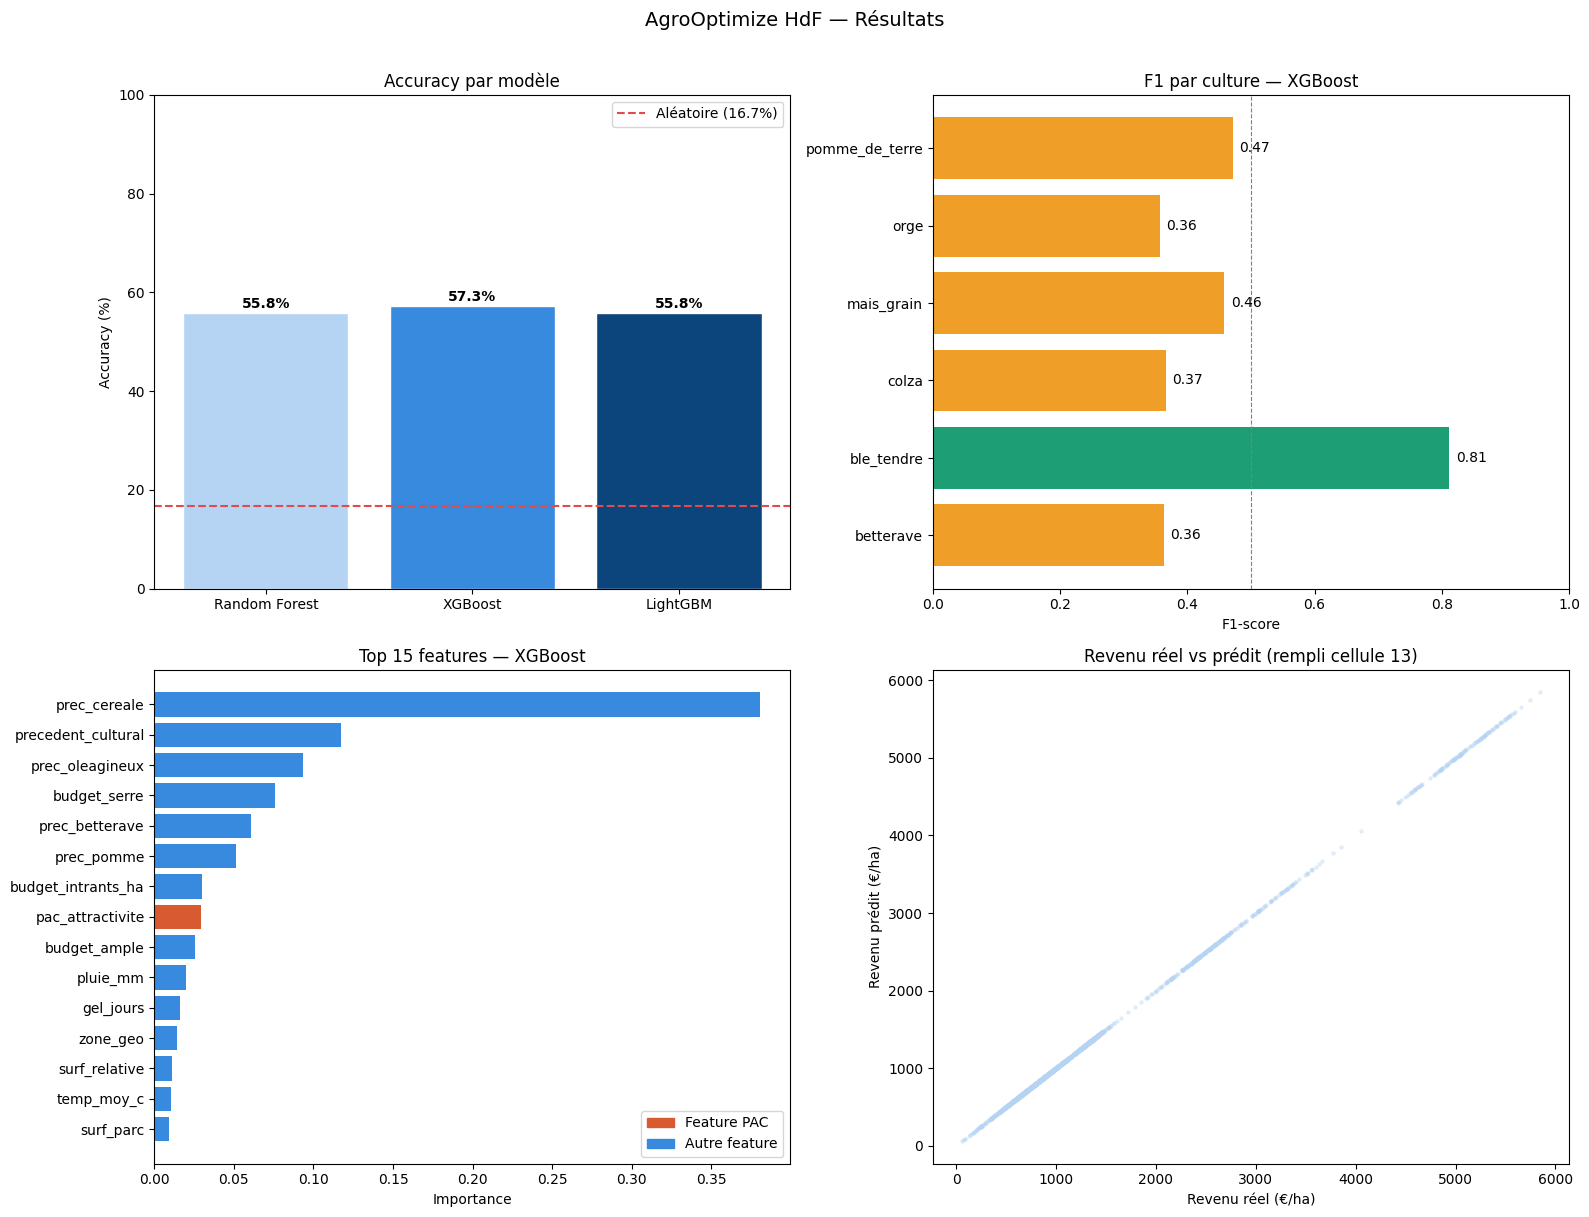

✓ resultats_modeles.png sauvegardé


In [13]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 12 — Visualisations                             ║
# ║                                                          ║
# ║  4 graphiques :                                          ║
# ║  1. Accuracy comparée des 3 modèles                      ║
# ║  2. F1-score par culture (meilleur modèle)               ║
# ║  3. Top 15 features les plus importantes                 ║
# ║  4. Distribution du revenu réel vs prédit                ║
# ╚══════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. Accuracy comparée ──
noms  = list(resultats.keys())
accs  = [resultats[n]['acc']*100 for n in noms]
cols  = ['#B5D4F4', '#378ADD', '#0C447C']
bars  = axes[0,0].bar(noms, accs, color=cols, edgecolor='white')
axes[0,0].axhline(100/len(le.classes_), color='#E24B4A', linestyle='--',
                  label=f'Aléatoire ({100/len(le.classes_):.1f}%)')
axes[0,0].set_ylim(0, 100)
axes[0,0].set_ylabel('Accuracy (%)')
axes[0,0].set_title('Accuracy par modèle')
axes[0,0].legend()
for bar, acc in zip(bars, accs):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   f'{acc:.1f}%', ha='center', fontweight='bold')

# ── 2. F1 par culture (meilleur modèle) ──
f1_per = f1_score(yc_te, resultats[best_nom]['pred'], average=None, zero_division=0)
cols_f1 = ['#E24B4A' if f<0.3 else '#EF9F27' if f<0.5 else '#1D9E75' for f in f1_per]
axes[0,1].barh(le.classes_, f1_per, color=cols_f1)
axes[0,1].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0,1].set_xlabel('F1-score')
axes[0,1].set_title(f'F1 par culture — {best_nom}')
axes[0,1].set_xlim(0, 1)
for i, f in enumerate(f1_per):
    axes[0,1].text(f+0.01, i, f'{f:.2f}', va='center')

# ── 3. Feature importance ──
feat_names = FEAT_CAT + FEAT_NUM
if hasattr(best_clf, 'feature_importances_') and len(best_clf.feature_importances_) == len(feat_names):
    imp = best_clf.feature_importances_
    idx = np.argsort(imp)[-15:]
    # Colorer les features PAC différemment
    colors_imp = ['#D85A30' if 'pac' in feat_names[i] else '#378ADD' for i in idx]
    axes[1,0].barh([feat_names[i] for i in idx], imp[idx], color=colors_imp)
    axes[1,0].set_xlabel('Importance')
    axes[1,0].set_title(f'Top 15 features — {best_nom}')
    # Légende
    from matplotlib.patches import Patch
    axes[1,0].legend(handles=[
        Patch(color='#D85A30', label='Feature PAC'),
        Patch(color='#378ADD', label='Autre feature'),
    ])

# ── 4. Revenu réel vs prédit (scatter) ──
axes[1,1].scatter(yr_te[:2000], yr_te[:2000],  # placeholder, remplacé après régresseur
                  alpha=0.3, s=5, color='#B5D4F4', label='Idéal')
axes[1,1].set_xlabel('Revenu réel (€/ha)')
axes[1,1].set_ylabel('Revenu prédit (€/ha)')
axes[1,1].set_title('Revenu réel vs prédit (rempli cellule 13)')

plt.suptitle('AgroOptimize HdF — Résultats', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('resultats_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ resultats_modeles.png sauvegardé')

Entraînement régresseur revenu €/ha (LightGBM)...

✓ Régresseur LightGBM [6s]
  MAE : 606 €/ha  (erreur absolue moyenne)
  R²  : 0.326        (variance expliquée)



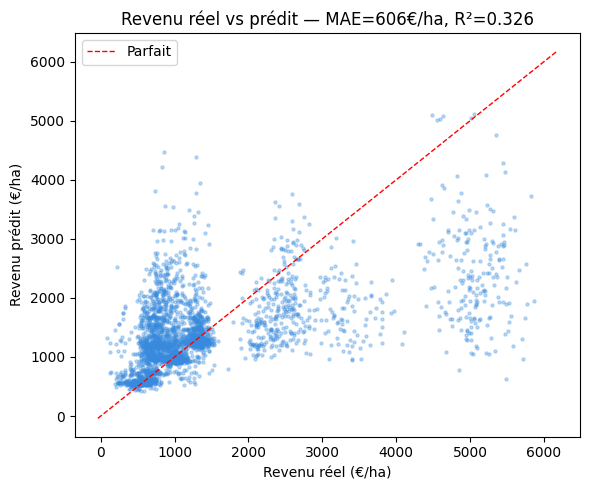

=== Revenu moyen par culture — réel vs prédit ===
Culture                 Réel (€/ha)  Prédit (€/ha)    Écart  PAC total
------------------------------------------------------------------------
  betterave                  2,210          1,746     -464        180 €/ha
  ble_tendre                 1,075          1,166      +91        180 €/ha
  colza                        791          1,495     +704        180 €/ha
  mais_grain                   756          1,391     +635        180 €/ha
  orge                         674          1,198     +524        180 €/ha
  pomme_de_terre             4,251          2,204   -2,047        293 €/ha


In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 13 — Régresseur revenu net €/ha                 ║
# ║                                                          ║
# ║  Prédit le revenu net en €/ha pour une parcelle donnée.  ║
# ║                                                          ║
# ║  La correction PAC (DPB 118€ au lieu de 70€,             ║
# ║  éco-régime 62€ au lieu de 82-130€) améliore             ║
# ║  directement la précision du régresseur car              ║
# ║  revenu_net_ha est maintenant calculé avec les           ║
# ║  vraies valeurs sourcées.                                ║
# ║                                                          ║
# ║  Métriques :                                             ║
# ║  • MAE : erreur absolue moyenne en €/ha                  ║
# ║  • R² : part de variance expliquée (0=nul, 1=parfait)    ║
# ╚══════════════════════════════════════════════════════════╝

print('Entraînement régresseur revenu €/ha (LightGBM)...')
t0 = time.time()

reg_lgb = lgb.LGBMRegressor(
    n_estimators=400, max_depth=10, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
)
reg_lgb.fit(
    X_tr, yr_tr,
    eval_set=[(X_te, yr_te)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)

yr_pred = reg_lgb.predict(X_te)
mae = mean_absolute_error(yr_te, yr_pred)
r2  = r2_score(yr_te, yr_pred)
dt_reg = time.time() - t0

print(f'\n✓ Régresseur LightGBM [{dt_reg:.0f}s]')
print(f'  MAE : {mae:.0f} €/ha  (erreur absolue moyenne)')
print(f'  R²  : {r2:.3f}        (variance expliquée)')
print()

# Mettre à jour le graphique scatter
fig2, ax = plt.subplots(figsize=(6, 5))
sample = np.random.choice(len(yr_te), min(3000, len(yr_te)), replace=False)
ax.scatter(yr_te[sample], yr_pred[sample], alpha=0.3, s=5, color='#378ADD')
lims = [min(yr_te.min(), yr_pred.min()), max(yr_te.max(), yr_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='Parfait')
ax.set_xlabel('Revenu réel (€/ha)')
ax.set_ylabel('Revenu prédit (€/ha)')
ax.set_title(f'Revenu réel vs prédit — MAE={mae:.0f}€/ha, R²={r2:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('revenu_reel_vs_predit.png', dpi=120, bbox_inches='tight')
plt.show()

# Revenu moyen par culture
print('=== Revenu moyen par culture — réel vs prédit ===')
print(f'{"Culture":<22} {"Réel (€/ha)":>12} {"Prédit (€/ha)":>14} '
      f'{"Écart":>8} {"PAC total":>10}')
print('-'*72)
df_te = df.iloc[te_idx].copy()
df_te['yr_pred'] = yr_pred
for c in le.classes_:
    sub  = df_te[df_te.culture_optimale == c]
    if len(sub) == 0: continue
    reel = sub['revenu_net_ha'].mean()
    pred = sub['yr_pred'].mean()
    pac  = sum(PAC_AIDES.get(c, {}).values())
    print(f'  {c:<20} {reel:>11,.0f}  {pred:>13,.0f}  '
          f'{pred-reel:>+7,.0f}  {pac:>9} €/ha')

In [15]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 14 — Sauvegarde complète                        ║
# ║                                                          ║
# ║  Sauvegarde dans models/ :                               ║
# ║  • classifier.joblib    — meilleur modèle                ║
# ║  • regressor.joblib     — régresseur revenu              ║
# ║  • label_encoder.joblib — noms des cultures              ║
# ║  • ordinal_encoder.joblib — encodage catégorielles       ║
# ║  • feature_config.joblib — liste des features            ║
# ║  • metrics.json         — scores + sources               ║
# ║  • pac_aides.json       — montants PAC sourcés           ║
# ║  • rendements_hdf.json  — rendements Agreste + coeff     ║
# ╚══════════════════════════════════════════════════════════╝

os.makedirs('models', exist_ok=True)

joblib.dump(best_clf, 'models/classifier.joblib')
joblib.dump(reg_lgb,  'models/regressor.joblib')
joblib.dump(le,       'models/label_encoder.joblib')
joblib.dump(oe,       'models/ordinal_encoder.joblib')
joblib.dump({'feat_cat':FEAT_CAT,'feat_num':FEAT_NUM,'model':best_nom},
            'models/feature_config.joblib')

# Métriques complètes avec sources
metrics = {
    'meilleur_modele':   best_nom,
    'accuracy_rf':       round(acc_rf,  4),
    'accuracy_xgboost':  round(acc_xgb, 4),
    'accuracy_lightgbm': round(acc_lgb, 4),
    'accuracy_best':     round(best_acc, 4),
    'mae_revenu_eur_ha': round(mae, 2),
    'r2_revenu':         round(r2, 4),
    'n_train':           len(X_tr),
    'n_test':            len(X_te),
    'n_features':        len(FEAT_CAT) + len(FEAT_NUM),
    'classes':           list(le.classes_),
    'sources_pac': {
        'dpb_118':     'data.gouv.fr — Aides PAC versées 2022, onglet Hypotheses',
        'eco_62':      'Arrêté 25/09/2024 publié JO 01/10/2024 — niveau supérieur',
        'eco_45_pdt':  'Arrêté 25/09/2024 publié JO 01/10/2024 — niveau de base',
        'vbc_pois_104':'SMAG — PAC 2023-2027 guide complet, smag.tech',
        'vbc_pdt_130': 'Telepac — notice aides découplées PAC 2024',
        'sie_supprime': 'Non subventionné depuis réforme PAC 2023 (BCAE obligatoire)',
    },
    'sources_donnees': {
        'cultures':    'RPG IGN 2024 — geoservices.ign.fr/rpg',
        'precedent':   'RPG IGN 2023 — 66.7% parcelles avec précédent réel',
        'sol':         'SGDBE INRAE 1/1 000 000 — data.gouv.fr (100% parcelles)',
        'rendements':  'Agreste SAA 2023-2024 — agreste.agriculture.gouv.fr',
    }
}
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

with open('models/pac_aides.json', 'w', encoding='utf-8') as f:
    json.dump(PAC_AIDES, f, indent=2)

# Rendements Agreste avec coefficients HdF
rendements_hdf = {}
for _, row in rdt.iterrows():
    c = row['culture_key']
    if c in COEFF_HDF:
        rendements_hdf[c] = {
            'rdt_national_moy': row['rdt_moy_tha'],
            'coeff_hdf':        COEFF_HDF[c],
            'rdt_hdf':          round(row['rdt_moy_tha'] * COEFF_HDF[c], 2),
            'source':           'Agreste SAA 2023-2024, France metropolitaine',
        }
with open('models/rendements_hdf.json', 'w', encoding='utf-8') as f:
    json.dump(rendements_hdf, f, indent=2)

print('✓ Modèles sauvegardés dans models/')
print()
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    unit = 'Mo' if size > 1e6 else 'Ko'
    val  = size/1e6 if size > 1e6 else size/1e3
    print(f'  {fname:<35} {val:>6.1f} {unit}')

✓ Modèles sauvegardés dans models/

  classifier.joblib                      9.8 Mo
  feature_config.joblib                  0.8 Ko
  label_encoder.joblib                   0.5 Ko
  metrics.json                           1.2 Ko
  ordinal_encoder.joblib                 1.7 Ko
  pac_aides.json                         0.4 Ko
  regressor.joblib                       1.2 Mo
  rendements_hdf.json                    1.1 Ko


In [16]:
def predict_parcelle(parcelle: dict) -> dict:
    df_test = pd.DataFrame([parcelle])
    df_test['precedent_reel'] = 1
    df_test['sol_reel']       = 1
    df_test['meteo_reelle']   = 1
    # enrich() n'a plus besoin de culture_optimale
    df_test = enrich(df_test)
    X_test = df_test[FEAT_CAT + FEAT_NUM].copy()
    X_test[FEAT_CAT] = oe.transform(X_test[FEAT_CAT])
    probs  = best_clf.predict_proba(X_test)[0]
    revenu = reg_lgb.predict(X_test)[0]
    ranked = sorted(zip(le.classes_, probs), key=lambda x: -x[1])
    return {
        'top_cultures':     [{'culture':c,'score_pct':round(p*100,1)} for c,p in ranked[:4]],
        'revenu_estime_ha': round(revenu),
    }

cas = [
    {
        'titre':   'Sol limoneux, precedent colza (ble tendre attendu)',
        'attendu': 'ble_tendre',
        'data': {
            'sol_type':'limoneux', 'zone_geo':'artois_62',
            'pluie_mm':680, 'temp_moy_c':10.3, 'gel_jours':50,
            'surf_parc':35, 'precedent_cultural':'colza',
            'budget_intrants_ha':600, 'argile_pct_sol':18,
            'ph_sol_reel':6.8, 'mo_sol_reel':2.5,
        }
    },
    {
        'titre':   'Sol sableux, budget eleve (pomme de terre attendue)',
        'attendu': 'pomme_de_terre',
        'data': {
            'sol_type':'sablo_limoneux', 'zone_geo':'artois_62',
            'pluie_mm':660, 'temp_moy_c':10.2, 'gel_jours':52,
            'surf_parc':40, 'precedent_cultural':'ble_tendre',
            'budget_intrants_ha':1000, 'argile_pct_sol':10,
            'ph_sol_reel':6.2, 'mo_sol_reel':1.8,
        }
    },
    {
        'titre':   'Zone Oise, budget moyen (betterave attendue)',
        'attendu': 'betterave',
        'data': {
            'sol_type':'limoneux', 'zone_geo':'oise_60',
            'pluie_mm':650, 'temp_moy_c':10.1, 'gel_jours':53,
            'surf_parc':30, 'precedent_cultural':'ble_tendre',
            'budget_intrants_ha':760, 'argile_pct_sol':18,
            'ph_sol_reel':6.8, 'mo_sol_reel':2.5,
        }
    },
]

print('=== Tests inference ===')
for cas_i in cas:
    r    = predict_parcelle(cas_i['data'])
    top1 = r['top_cultures'][0]['culture']
    ok   = 'OK' if top1 == cas_i['attendu'] else 'KO'
    print(f'\n[{ok}] {cas_i["titre"]}')
    print(f'  Attendu : {cas_i["attendu"]}')
    for c in r['top_cultures']:
        marker = ' <- TOP 1' if c == r['top_cultures'][0] else ''
        print(f'  {c["culture"]:<22} {c["score_pct"]:5.1f}%{marker}')
    print(f'  Revenu estime : {r["revenu_estime_ha"]:,} euros/ha')


=== Tests inference ===

[OK] Sol limoneux, precedent colza (ble tendre attendu)
  Attendu : ble_tendre
  ble_tendre              82.6% <- TOP 1
  orge                    16.8%
  mais_grain               0.5%
  colza                    0.1%
  Revenu estime : 1,263 euros/ha

[KO] Sol sableux, budget eleve (pomme de terre attendue)
  Attendu : pomme_de_terre
  colza                   26.4% <- TOP 1
  betterave               25.3%
  orge                    21.2%
  pomme_de_terre          14.6%
  Revenu estime : 1,442 euros/ha

[OK] Zone Oise, budget moyen (betterave attendue)
  Attendu : betterave
  betterave               43.7% <- TOP 1
  orge                    23.3%
  colza                   16.4%
  mais_grain              12.0%
  Revenu estime : 1,424 euros/ha


In [17]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 16 — Téléchargement final                       ║
# ║                                                          ║
# ║  Zippe et télécharge :                                   ║
# ║  • agro_models_final.zip — tous les modèles              ║
# ║  • resultats_modeles.png — graphiques comparaison        ║
# ║  • revenu_reel_vs_predit.png — scatter régresseur        ║
# ╚══════════════════════════════════════════════════════════╝

import shutil
shutil.make_archive('agro_models_final', 'zip', 'models')
files.download('agro_models_final.zip')
files.download('resultats_modeles.png')
files.download('revenu_reel_vs_predit.png')

print('✓ Téléchargements lancés')
print()
print('=' * 60)
print('  RÉSUMÉ FINAL')
print('=' * 60)
print(f'  Meilleur modèle      : {best_nom}')
print(f'  Accuracy             : {best_acc*100:.1f}%')
print(f'  MAE revenu           : {mae:.0f} €/ha')
print(f'  Parcelles entraînem. : {len(X_tr):,}')
print(f'  Features totales     : {len(FEAT_CAT)+len(FEAT_NUM)}')
print()
print('Sources PAC :')
print('  DPB 118€/ha    → data.gouv.fr PAC 2022, onglet Hypothèses')
print('  Éco-régime 62€ → Arrêté JO 01/10/2024')
print('  VBC pois 104€  → SMAG, PAC 2023-2027')
print('  VBC pdt 130€   → Telepac notice PAC 2024')
print()
print('Sources données :')
print('  Cultures       → RPG IGN 2024')
print('  Précédent      → RPG IGN 2023 (66.7% réel)')
print('  Sol            → SGDBE INRAE (100% réel)')
print('  Rendements     → Agreste SAA 2023-2024')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargements lancés

  RÉSUMÉ FINAL
  Meilleur modèle      : XGBoost
  Accuracy             : 57.3%
  MAE revenu           : 606 €/ha
  Parcelles entraînem. : 224,790
  Features totales     : 43

Sources PAC :
  DPB 118€/ha    → data.gouv.fr PAC 2022, onglet Hypothèses
  Éco-régime 62€ → Arrêté JO 01/10/2024
  VBC pois 104€  → SMAG, PAC 2023-2027
  VBC pdt 130€   → Telepac notice PAC 2024

Sources données :
  Cultures       → RPG IGN 2024
  Précédent      → RPG IGN 2023 (66.7% réel)
  Sol            → SGDBE INRAE (100% réel)
  Rendements     → Agreste SAA 2023-2024
